In [1]:
%reset -f
from main import cost_func, aero_cost
import pygad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Starting variables
wingspan = 3.31 # 1 m
mid_chord = 0.13 # 15 cm
tip_chord = 0.05 # 15 cm
w_flange = 0.15*0.005
t_flange = 0.00001
t_web = 0.00001
t_skin_root = 0.00001 # 1 mm
t_skin_mid = 0.00001
t_skin_tip = 0.00001
mid_twist = -1.4 # 0 deg
tip_twist = -0.3 # 0 deg
skin_index = 0
spar_index = 0

# # Hard-code these values into cost equation
# spar_volume = 0.303*0.15*0.05*wingspan
# S = wing_area(wingspan, mid_chord, tip_chord)
# skin_volume = 2*S*t_skin
# V_maxR, Preq, _, _ = aero(wingspan, mid_chord, tip_chord, root_twist, mid_twist, tip_twist, spar_mat, skin_mat, spar_volume, skin_volume, 0, 0)
# desired_range = range(V_maxR, Preq)
# desired_cost = price(spar_mat, skin_mat, spar_volume, skin_volume)



In [3]:
func_inputs = [wingspan, mid_chord, tip_chord, w_flange, t_flange, t_web, t_skin_root, t_skin_mid, t_skin_tip, mid_twist, tip_twist, skin_index, spar_index]

In [4]:
def fitness_func(ga_instance, solution, solution_idx):
    cost = cost_func(solution[0], solution[1], solution[2], solution[3], solution[4], solution[5], solution[6], solution[7], solution[8], solution[9], solution[10], solution[11], solution[12])
    fitness = 1/cost
    return fitness


In [5]:
# population_history = []

def on_gen(ga_instance):

    # solution, fitness, idx = ga_instance.best_solution()
    # population_history.append(ga_instance.population.copy())

    if ga_instance.generations_completed % 5 == 0:
        solution, fitness, _ = ga_instance.best_solution()

        print(f"Gen {ga_instance.generations_completed} | Best Fitness = {fitness}")
        print("Design Variables:")
        print(f"Wingspan: {solution[0]}")
        print(f"Mid chord: {solution[1]}")
        print(f"Tip chord: {solution[2]}")
        print(f"Flange width: {solution[3]}")
        print(f"Flange thickness: {solution[4]}")
        print(f"Web thickness: {solution[5]}")
        print(f"Skin root thickness: {solution[6]}")
        print(f"Skin mid thickness: {solution[7]}")
        print(f"Skin tip thickness: {solution[8]}")
        print(f"Mid twist: {solution[9]}")
        print(f"Tip twist: {solution[10]}")
        print(f"Skin material: {solution[11]}")
        print(f"Spar material: {solution[12]}")


In [6]:
gene_space = [
    {'low':0.3, 'high':10}, # wingspan
    {'low':0.1, 'high':0.15}, # mid chord
    {'low':0.05, 'high':0.1}, # tip chord
    {'low':1e-5, 'high':7.575e-3}, # flange_width
    {'low':1e-5, 'high':7.575e-3}, # flange_thickness
    {'low':1e-5, 'high':7.575e-3}, # web_thickness
    {'low':1e-5, 'high':7.575e-3}, # skin thickness
    {'low':1e-5, 'high':5.05e-3}, # skin thickness
    {'low':1e-5, 'high':2.525e-3}, # skin thickness
    {'low':-5, 'high':0}, # mid twist
    {'low':-5, 'high':0}, # tip twist
    [0,1,2,3], # skin material
    [0,1,2,3] # spar material
]

gene_type = [
    float, # wingspan
    float, # mid chord
    float, # tip chord
    float, # flange width
    float, # flange thickness
    float, # flange thickness
    float, # flange thickness
    float, # web thickness
    float, # skin thickness
    float, # mid twist
    float, # tip twist
    int, # skin material
    int # spar material
]


# init_pop = [
#     [5.00, 0.15, 0.15, 0, 0, 0],
#     # [4.29, 0.115, 0.048, -3.19, -1.399, -1.58],
#     [4.3, 0.1, 0.04, -3.1, -1.4, -1.5],
#     [4.4, 0.1, 0.05, -3, -1, -2],
#     [3.31, 0.13, 0.05, -2.25, -1.4, -0.3],
#     [8.00, 0.15, 0.15, 0, -2, -3],
#     [4.00, 0.10, 0.08, -3.0, -2.0, 0],
#     [10.0, 0.15, 0.15, -5, -3, -1],
#     [1.00, 0.12, 0.08, 0, 0, 0],
#     [18.0, 0.15, 0.15, 0, 0, 0],
#     [6.2, 0.14, 0.08, -4, -2, -3],
#     [7.4, 0.10, 0.05, -3, -2, -1],
#     # [9.00, 0.11, 0.10, 0, 0, 0]
# ]

# init_pop = [
#     [5.00, 0.15, 0.15, 0, 0, 0],
#     [4.29, 0.115, 0.048, -3.19, -1.399, -1.58],
#     [4.4, 0.1, 0.05, -3, -1, -2],
#     [3.31, 0.13, 0.05, -2.25, -1.4, -0.3],
# ]

# gene_df = pd.DataFrame(gene_space)

# random_init_pop = np.random.uniform(gene_df['low'], gene_df['high'], size=(60-len(init_pop), len(func_inputs)))

# initial_pop = np.vstack((init_pop, random_init_pop))

ga_inst = pygad.GA(num_generations=100, # number of generations run
                  num_parents_mating=10, # how many of best solutions are selected to be parents in the next, roughly half of or less than half of sol_per_pop
                  sol_per_pop=60, # each population has this many solutions, only meaningful if initial_population is not used, small value might prevent finding high-quality solutions, large value might lead to unnecessary computational expense
                  keep_parents=2, # contols elitism, how many parents from current generation are carried to the next, typically 1 or 2
                  num_genes=len(func_inputs), # each solution has this many genes with constraints set by gene_space
                  fitness_func=fitness_func,
                #   initial_population=init_pop,
                  parent_selection_type="tournament",
                  K_tournament=3,
                  crossover_type="uniform",
                  mutation_type="random",
                  mutation_percent_genes=25, # increased from 25
                #   mutation_type="adaptive",
                #   mutation_percent_genes=[30,5],
                  gene_space=gene_space, # use instead of init_range_low/high, constraints to genes
                  gene_type=gene_type, # value type for genes
                  on_generation=on_gen)

ga_inst.run()

# try with existing or known result

Gen 5 | Best Fitness = 1.6777224189235567
Design Variables:
Wingspan: 0.562188853943087
Mid chord: 0.11734992022071566
Tip chord: 0.06626396926115141
Flange width: 0.0005711075910919864
Flange thickness: 0.002807723547654259
Web thickness: 0.003289993953530478
Skin root thickness: 0.00020575623385440966
Skin mid thickness: 0.0001311624737934914
Skin tip thickness: 0.0013393591562331946
Mid twist: -0.43653936888408573
Tip twist: -1.1384659543077458
Skin material: 1
Spar material: 1
Gen 10 | Best Fitness = 1.6777224189335018
Design Variables:
Wingspan: 0.562188853943087
Mid chord: 0.13251185769386628
Tip chord: 0.05540332848526755
Flange width: 0.00526937041765639
Flange thickness: 0.001709132547131684
Web thickness: 0.0006797316650028664
Skin root thickness: 0.00020575623385440966
Skin mid thickness: 0.0007714228292245202
Skin tip thickness: 0.0018246485413840102
Mid twist: -1.7745148974258909
Tip twist: -2.676984479859908
Skin material: 1
Spar material: 1
Gen 15 | Best Fitness = 1.6777

KeyboardInterrupt: 

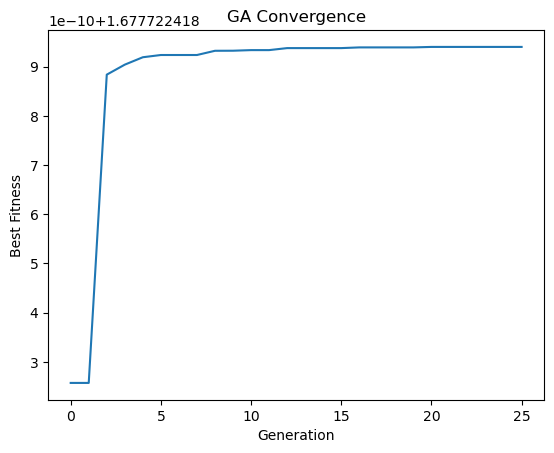

In [7]:
plt.plot(ga_inst.best_solutions_fitness)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

In [ ]:
# solution, fitness, _ = ga_inst.best_solution()

In [ ]:
ga_inst.save(filename="run_1")

In [ ]:
# population_history = np.array(population_history)